In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

In [3]:
train_df.count()

Id               1460
MSSubClass       1460
MSZoning         1460
LotFrontage      1201
LotArea          1460
                 ... 
MoSold           1460
YrSold           1460
SaleType         1460
SaleCondition    1460
SalePrice        1460
Length: 81, dtype: int64

In [4]:
test_df.count()

Id               1459
MSSubClass       1459
MSZoning         1455
LotFrontage      1232
LotArea          1459
                 ... 
MiscVal          1459
MoSold           1459
YrSold           1459
SaleType         1458
SaleCondition    1459
Length: 80, dtype: int64

In [5]:
y = train_df["SalePrice"]
train_df = train_df.drop("SalePrice", axis=1)

In [6]:
df = pd.concat([train_df, test_df], axis=0)

In [7]:
df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2919 entries, 0 to 1458
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             2919 non-null   int64  
 1   MSSubClass     2919 non-null   int64  
 2   MSZoning       2915 non-null   object 
 3   LotFrontage    2433 non-null   float64
 4   LotArea        2919 non-null   int64  
 5   Street         2919 non-null   object 
 6   Alley          198 non-null    object 
 7   LotShape       2919 non-null   object 
 8   LandContour    2919 non-null   object 
 9   Utilities      2917 non-null   object 
 10  LotConfig      2919 non-null   object 
 11  LandSlope      2919 non-null   object 
 12  Neighborhood   2919 non-null   object 
 13  Condition1     2919 non-null   object 
 14  Condition2     2919 non-null   object 
 15  BldgType       2919 non-null   object 
 16  HouseStyle     2919 non-null   object 
 17  OverallQual    2919 non-null   int64  
 18  OverallCond  

In [9]:
a = np.array(df.isnull().sum().to_dict())
a

array({'Id': 0, 'MSSubClass': 0, 'MSZoning': 4, 'LotFrontage': 486, 'LotArea': 0, 'Street': 0, 'Alley': 2721, 'LotShape': 0, 'LandContour': 0, 'Utilities': 2, 'LotConfig': 0, 'LandSlope': 0, 'Neighborhood': 0, 'Condition1': 0, 'Condition2': 0, 'BldgType': 0, 'HouseStyle': 0, 'OverallQual': 0, 'OverallCond': 0, 'YearBuilt': 0, 'YearRemodAdd': 0, 'RoofStyle': 0, 'RoofMatl': 0, 'Exterior1st': 1, 'Exterior2nd': 1, 'MasVnrType': 1766, 'MasVnrArea': 23, 'ExterQual': 0, 'ExterCond': 0, 'Foundation': 0, 'BsmtQual': 81, 'BsmtCond': 82, 'BsmtExposure': 82, 'BsmtFinType1': 79, 'BsmtFinSF1': 1, 'BsmtFinType2': 80, 'BsmtFinSF2': 1, 'BsmtUnfSF': 1, 'TotalBsmtSF': 1, 'Heating': 0, 'HeatingQC': 0, 'CentralAir': 0, 'Electrical': 1, '1stFlrSF': 0, '2ndFlrSF': 0, 'LowQualFinSF': 0, 'GrLivArea': 0, 'BsmtFullBath': 2, 'BsmtHalfBath': 2, 'FullBath': 0, 'HalfBath': 0, 'BedroomAbvGr': 0, 'KitchenAbvGr': 0, 'KitchenQual': 1, 'TotRmsAbvGrd': 0, 'Functional': 2, 'Fireplaces': 0, 'FireplaceQu': 1420, 'GarageType'

In [10]:
drop_cols = ['Alley','PoolQC','Fence','MiscFeature']
df.drop(columns=drop_cols, inplace=True)

In [11]:
df["HouseAge"] = df["YrSold"] - df["YearBuilt"]
df["RemodelAge"] = df["YrSold"] - df["YearRemodAdd"]
df["GarageAge"] = df["YrSold"] - df["GarageYrBlt"]

In [12]:
df.drop(["YearBuilt","YearRemodAdd","GarageYrBlt"], axis=1, inplace=True)

In [13]:
num_col = make_column_selector(dtype_include=np.number)
cat_col = make_column_selector(dtype_exclude=np.number)

In [14]:
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [15]:
preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_col),
    ("cat", cat_pipeline, cat_col)
])

In [16]:
X_train = df.iloc[:len(y), :]
X_test = df.iloc[len(y):, :]

In [17]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y, test_size=0.2, random_state=42
)

## RandomForest

In [18]:
from sklearn.ensemble import RandomForestRegressor
rf = Pipeline([
    ("preprocessing", preprocessor),
    ("model", RandomForestRegressor(n_estimators=200, random_state=42))
])
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_val)
rf_mse = mean_squared_error(y_val, rf_pred)
rf_mae = mean_absolute_error(y_val, rf_pred)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_val, rf_pred)
print("MSE:", rf_mse)
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R2 Score:", rf_r2)

MSE: 824326148.9239066
MAE: 17488.762791095887
RMSE: 28711.080594848856
R2 Score: 0.8925304965320107


## Decision Tree

In [19]:
from sklearn.tree import DecisionTreeRegressor
dt = Pipeline([
    ("preprocessing", preprocessor),
    ("model", DecisionTreeRegressor(random_state=42))
])
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_val)
dt_mse = mean_squared_error(y_val, dt_pred)
dt_mae = mean_absolute_error(y_val, dt_pred)
dt_rmse = np.sqrt(dt_mse)
dt_r2 = r2_score(y_val, dt_pred)
print("MSE:", dt_mse)
print("MAE:", dt_mae)
print("RMSE:",dt_rmse )
print("R2 Score:", dt_r2)

MSE: 1589639587.4828768
MAE: 25858.640410958906
RMSE: 39870.284517205
R2 Score: 0.7927546306970128


## XGBooster

In [20]:
from xgboost import XGBRegressor
xgb = Pipeline([
    ("preprocessing", preprocessor),
    ("model", XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=5, random_state=42))
])
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_val)
xgb_mse = mean_squared_error(y_val, xgb_pred)
xgb_mae = mean_absolute_error(y_val, xgb_pred)
xgb_rmse = np.sqrt(xgb_mse)
xgb_r2 = r2_score(y_val, xgb_pred)
print("MSE:", xgb_mse)
print("MAE:", xgb_mae)
print("RMSE:", xgb_rmse)
print("R2 Score:", xgb_r2)

MSE: 637761600.0
MAE: 15524.8701171875
RMSE: 25253.94226650564
R2 Score: 0.9168533682823181


## Gradient Boosting

In [21]:
from sklearn.ensemble import GradientBoostingRegressor
gbr = Pipeline([
    ("preprocessing", preprocessor),
    ("model", GradientBoostingRegressor(n_estimators=500, learning_rate=0.05, max_depth=5, random_state=42))
])
gbr.fit(X_train, y_train)
gbr_pred = gbr.predict(X_val)
gbr_mse = mean_squared_error(y_val, gbr_pred)
gbr_mae = mean_absolute_error(y_val, gbr_pred)
gbr_rmse = np.sqrt(gbr_mse)
gbr_r2 = r2_score(y_val, gbr_pred)
print("MSE:", gbr_mse)
print("MAE:", gbr_mae)
print("RMSE:", gbr_rmse)
print("R2 Score:", gbr_r2)

MSE: 644962485.8102309
MAE: 15857.365959889441
RMSE: 25396.1116277715
R2 Score: 0.9159145949743444


## Hyperparameter of XGBoost

In [ ]:
from sklearn.model_selection import GridSearchCV
xgb_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", XGBRegressor(
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    ))
])
param_grid = {
    "model__n_estimators": [300, 500, 700],
    "model__max_depth": [3, 5, 7],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__subsample": [0.7, 0.8, 1.0],
    "model__colsample_bytree": [0.7, 0.8, 1.0],
    "model__gamma": [0, 1, 5]
}
grid_search = GridSearchCV(
    xgb_pipeline,
    param_grid,
    cv=3,
    scoring="neg_root_mean_squared_error",
    verbose=2,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_val)

In [29]:
print("Best Parameters:", grid_search.best_params_)
grid_xbg_mse = mean_squared_error(y_val, y_pred)
grid_xbg_mae = mean_absolute_error(y_val, y_pred)
grid_xbg_rmse = np.sqrt(grid_xbg_mse)
grid_xbg_r2 = r2_score(y_val, y_pred)
print("MSE:", grid_xbg_mse)
print("MAE:", grid_xbg_mae)
print("RMSE:", grid_xbg_rmse)
print("R2 Score:", grid_xbg_r2)

Best Parameters: {'model__colsample_bytree': 0.7, 'model__gamma': 0, 'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 700, 'model__subsample': 0.8}
MSE: 591047424.0
MAE: 15088.2607421875
RMSE: 24311.46692406692
R2 Score: 0.922943651676178


In [31]:
import pandas as pd
metrics_df = pd.DataFrame({
    "Model": ["Random Forest", "Decision Tree", "XGBoost", "GradientBoosting", "Hyperparameter of XGBOOst"],
    "MSE": [rf_mse, dt_mse, xgb_mse, gbr_mse, grid_xbg_mse],
    "MAE": [rf_mae, dt_mae, xgb_mae, gbr_mae, grid_xbg_mae],
    "RMSE": [rf_rmse, dt_rmse, xgb_rmse, gbr_rmse, grid_xbg_rmse],
    "R2": [rf_r2, dt_r2, xgb_r2, gbr_r2, grid_xbg_r2]
})
metrics_df

,Model,MSE,MAE,RMSE,R2
0,Random Forest,8.243261e+08,17488.762791,28711.080595,0.892530
1,Decision Tree,1.589640e+09,25858.640411,39870.284517,0.792755
2,XGBoost,6.377616e+08,15524.870117,25253.942267,0.916853
3,GradientBoosting,6.449625e+08,15857.365960,25396.111628,0.915915
4,Hyperparameter of XGBOOst,5.910474e+08,15088.260742,24311.466924,0.922944


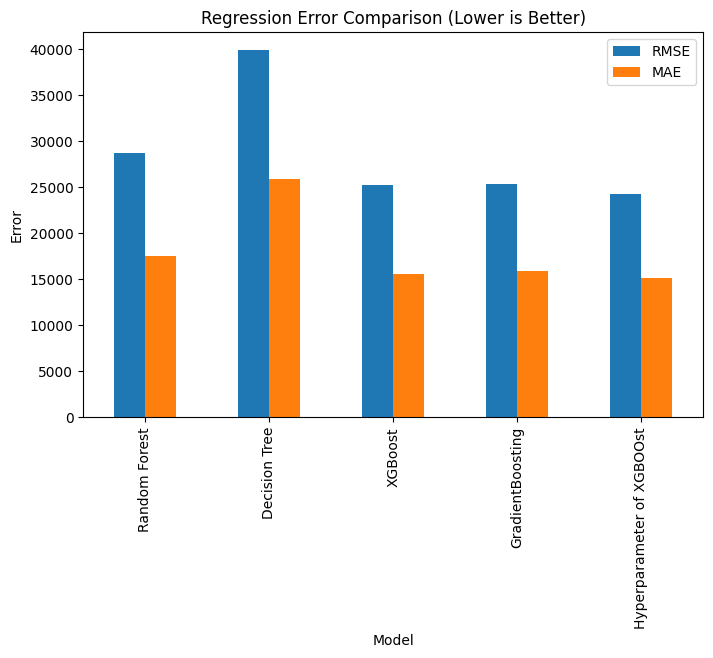

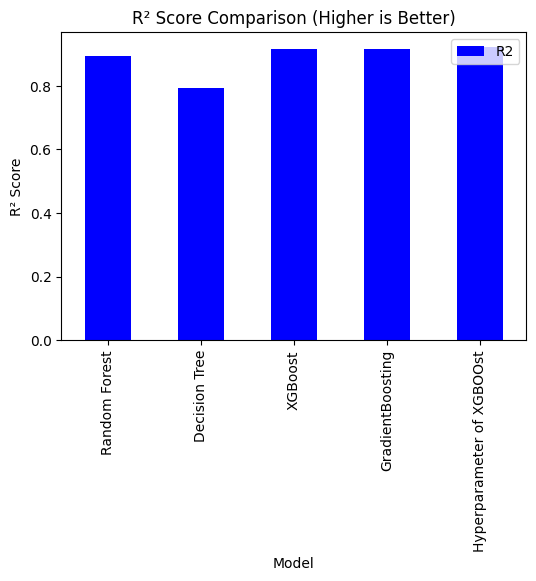

In [32]:
import matplotlib.pyplot as plt
# Errors
metrics_df.set_index("Model")[["RMSE","MAE"]].plot(kind="bar", figsize=(8,5))
plt.title("Regression Error Comparison (Lower is Better)")
plt.ylabel("Error")
plt.legend()
plt.show()

# R²
metrics_df.set_index("Model")[["R2"]].plot(kind="bar", figsize=(6,4), color="blue")
plt.title("R² Score Comparison (Higher is Better)")
plt.ylabel("R² Score")
plt.legend()
plt.show()

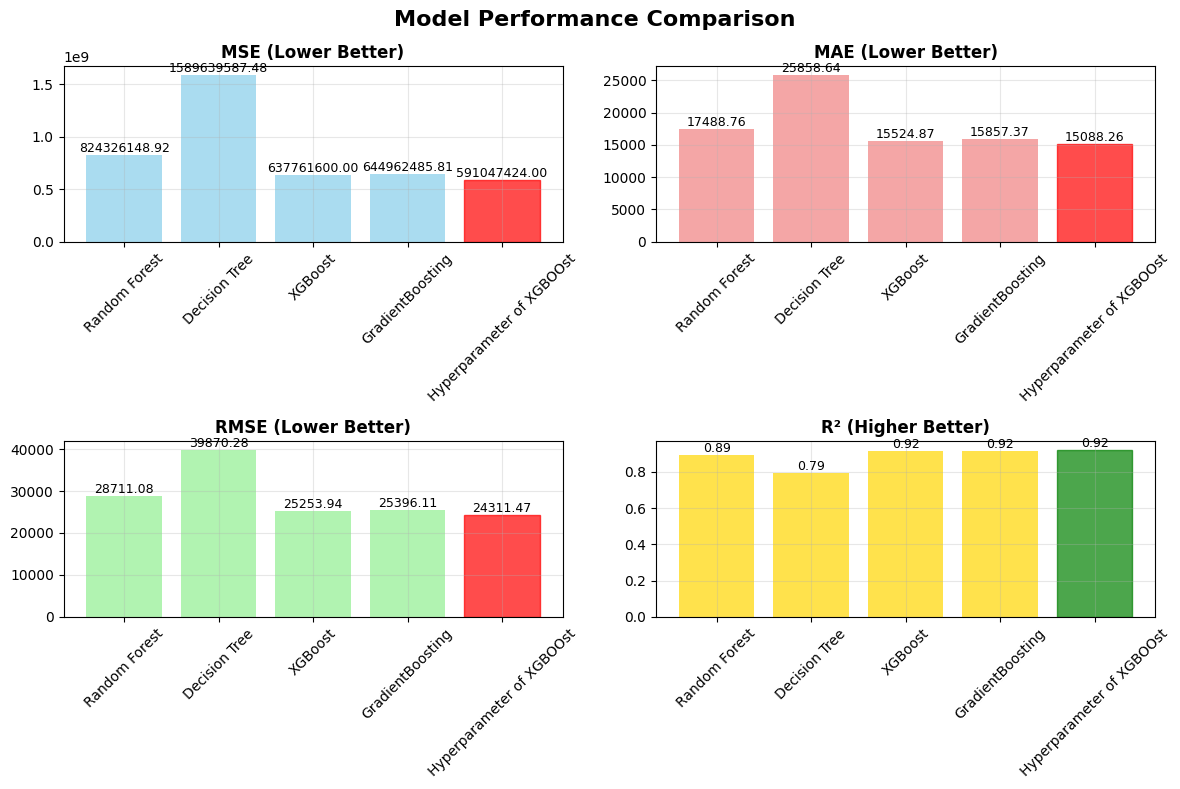

In [33]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold')
metrics_to_plot = ["MSE", "MAE", "RMSE", "R2"]
titles = ["MSE (Lower Better)", "MAE (Lower Better)", 
          "RMSE (Lower Better)", "R² (Higher Better)"]
colors = ['skyblue', 'lightcoral', 'lightgreen', 'gold']
for idx, (metric, title, color) in enumerate(zip(metrics_to_plot, titles, colors)):
    ax = axes[idx//2, idx%2]
    bars = ax.bar(metrics_df["Model"], metrics_df[metric], color=color, alpha=0.7)
    if metric == "R2":
        best_idx = metrics_df[metric].idxmax()
    else:
        best_idx = metrics_df[metric].idxmin()
    
    bars[best_idx].set_color('green' if metric == "R2" else 'red')
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height,
                f'{height:.2f}', ha='center', va='bottom', fontsize=9)
    
    ax.set_title(title, fontweight='bold')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Conclusion

In [34]:
print("\n=== ERROR METRICS (Lower is Better) ===")
for metric in ["MSE", "MAE", "RMSE"]:
    best_model = metrics_df.loc[metrics_df[metric].idxmin(), "Model"]
    best_value = metrics_df[metric].min()
    print(f"{metric}: {best_model} ({best_value:.2f})")


=== ERROR METRICS (Lower is Better) ===
MSE: Hyperparameter of XGBOOst (591047424.00)
MAE: Hyperparameter of XGBOOst (15088.26)
RMSE: Hyperparameter of XGBOOst (24311.47)


In [35]:
print("\n=== R² SCORE (Higher is Better) ===")
best_r2_model = metrics_df.loc[metrics_df["R2"].idxmax(), "Model"]
best_r2 = metrics_df["R2"].max()
print(f"R²: {best_r2_model} ({best_r2*100:.4f})")


=== R² SCORE (Higher is Better) ===
R²: Hyperparameter of XGBOOst (92.2944)
